# Caso: Comportamiento Web
**Descripción:** Una empresa desea analizar el comportamiento web: tasa de clics y duración de sesión.

**Objetivo:** Identificar patrones de navegación.

**Diccionario de datos:**
- `click_rate`: Tasa de clics por sesión.
- `session_duration`: Minutos de duración de la sesión.

## Paso 1: Carga de datos

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset
df = pd.read_csv("/mnt/Comportamiento_Web.csv")
df.head()

,click_rate,session_duration
0,1.287740,7.181769
1,4.405529,8.622329
2,3.044851,2.804105
3,1.916049,25.587846
4,2.629311,8.148042


## Paso 2: Preprocesamiento

In [9]:
# Normalización
scaler = StandardScaler()
X = scaler.fit_transform(df)

## Paso 3: Clustering con DBSCAN

In [16]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X)
df['DBSCAN'] = labels_dbscan

## Paso 4: Clustering con Mean-Shift

In [17]:
bandwidth = estimate_bandwidth(X, quantile=0.2, n_samples=1000)
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels_ms = ms.fit_predict(X)
df['MeanShift'] = labels_ms

## Paso 5: Visualización de Resultados

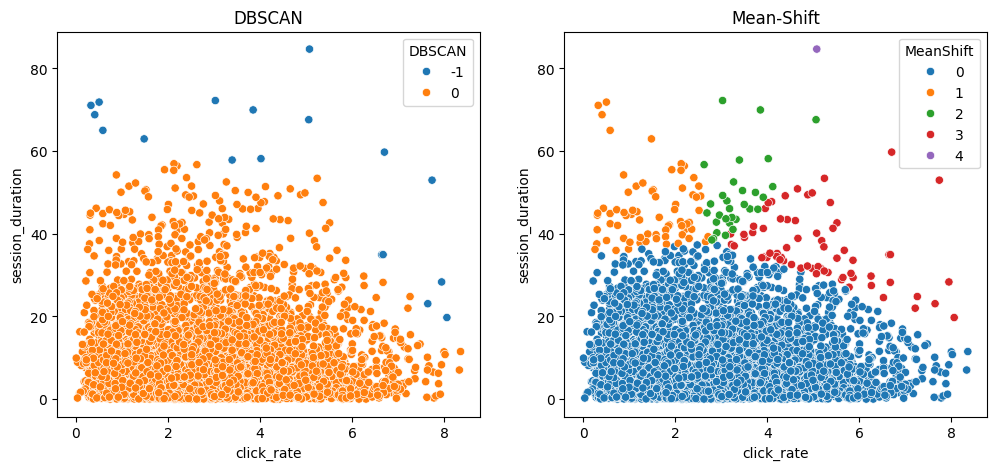

In [18]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(x=df.iloc[:,0], y=df.iloc[:,1], hue=df['DBSCAN'], palette='tab10')
plt.title("DBSCAN")

plt.subplot(1,2,2)
sns.scatterplot(x=df.iloc[:,0], y=df.iloc[:,1], hue=df['MeanShift'], palette='tab10')
plt.title("Mean-Shift")
plt.show()

## Paso 6: Evaluación con Silhouette Score

In [13]:
def safe_silhouette(X, labels):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    return silhouette_score(X, labels) if n_clusters > 1 else -1

score_dbscan = safe_silhouette(X, df['DBSCAN'])
score_meanshift = safe_silhouette(X, df['MeanShift'])

print(f"Silhouette DBSCAN: {score_dbscan:.4f}")
print(f"Silhouette Mean-Shift: {score_meanshift:.4f}")

Silhouette DBSCAN: 0.6694
Silhouette Mean-Shift: 0.4940


## Paso 7: Conclusiones

In [14]:
if score_dbscan > score_meanshift:
    print("DBSCAN obtuvo un mejor desempeño en este caso.")
elif score_meanshift > score_dbscan:
    print("Mean-Shift obtuvo un mejor desempeño en este caso.")
else:
    print("Ambos algoritmos obtuvieron resultados similares o no fueron efectivos.")

DBSCAN obtuvo un mejor desempeño en este caso.


✅ ¿Por qué DBSCAN fue mejor esta vez?
Mayor claridad de separación:

1. DBSCAN detectó solo los puntos realmente agrupados, y excluyó los dispersos (como outliers).

 * Eso genera una alta separación entre "grupo denso" y "ruido", lo que mejora el score.

 * Mean-Shift fue más permisivo:

2. Agrupó puntos que estaban más dispersos.

 * Formó clusters que se solapan o no están bien definidos.

 * *Esto reduce la cohesión interna de cada cluster y el Silhouette cae.

 * Silhouette penaliza clusters mal definidos:

3. Prefiere pocos clusters bien separados y compactos, en lugar de muchos pero mal formados.

 * DBSCAN cumple eso mejor aquí.